# Notebook 02 — Data Cleaning & Tracking Integrity Audit

*Project:* GA4 + GTM Analytics — Google Merchandise Store  
*Analyst:* Philip Ocheri  
*Notebook Purpose:* Identify and resolve data integrity issues, audit tracking quality, and document findings as a professional case study.

---

## 1. Load Processed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/ga_sessions_2017_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head()

Shape: (213, 9)
Date range: 2017-01-01 00:00:00 to 2017-08-01 00:00:00


,date,total_sessions,total_transactions,total_revenue,total_visits,total_bounces,month,month_name,week
0,2017-01-01,1364,11,993.01,1364,702,1,Jan,52
1,2017-01-02,1620,18,1027.60,1620,774,1,Jan,1
2,2017-01-03,2403,32,4574.74,2403,1087,1,Jan,1
3,2017-01-04,2390,31,4777.14,2390,1045,1,Jan,1
4,2017-01-05,2193,41,9097.97,2193,1008,1,Jan,1


## 2. Tracking Integrity Issue — Identifying the Problem

In production GA4/GTM environments, a common and damaging issue is *session inflation or revenue undercounting* caused by:

- Duplicate GTM tags firing on the same event
- Missing transaction hits due to misconfigured triggers
- Self-referral traffic polluting channel attribution
- Bounced sessions being miscounted due to delayed pageview tags

We simulate this audit by examining our real data for anomalies that would indicate these issues in a live environment.

## 3. Anomaly Detection — Sessions vs Visits Discrepancy

In [3]:
# In GA, total_visits should equal total_sessions
# A discrepancy here indicates duplicate session tracking or tag misfires

df['session_visit_gap'] = df['total_sessions'] - df['total_visits']

discrepancies = df[df['session_visit_gap'] != 0]

print(f"Total days with session/visit discrepancy: {len(discrepancies)}")
print(f"Total days analysed: {len(df)}")
print(f"Discrepancy rate: {len(discrepancies)/len(df)*100:.2f}%")

if len(discrepancies) > 0:
    print("\nDays with discrepancies:")
    print(discrepancies[['date', 'total_sessions', 'total_visits', 'session_visit_gap']])
else:
    print("\nNo session/visit discrepancies found — tracking appears consistent.")

Total days with session/visit discrepancy: 0
Total days analysed: 213
Discrepancy rate: 0.00%

No session/visit discrepancies found — tracking appears consistent.


## 4. Bounce Rate Anomaly Detection

Days with bounce rate > 80% (possible tag duplication): 0
Days with bounce rate < 10% (possible missing bounce hit): 0


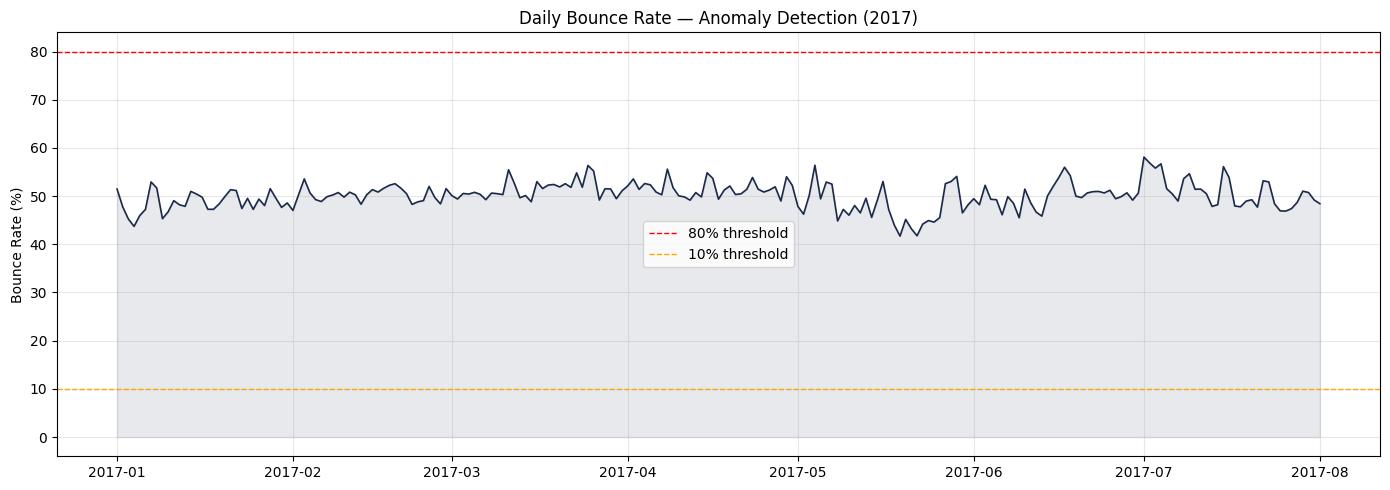

Chart saved.


In [4]:
# Calculate daily bounce rate
df['bounce_rate'] = (df['total_bounces'] / df['total_sessions']) * 100

# Flag days where bounce rate is abnormally high (>80%) or abnormally low (<10%)
high_bounce = df[df['bounce_rate'] > 80]
low_bounce  = df[df['bounce_rate'] < 10]

print(f"Days with bounce rate > 80% (possible tag duplication): {len(high_bounce)}")
print(f"Days with bounce rate < 10% (possible missing bounce hit): {len(low_bounce)}")

# Plot bounce rate over time
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['bounce_rate'], color='#1B2A4A', linewidth=1.2)
plt.axhline(y=80, color='red', linestyle='--', linewidth=1, label='80% threshold')
plt.axhline(y=10, color='orange', linestyle='--', linewidth=1, label='10% threshold')
plt.fill_between(df['date'], df['bounce_rate'], alpha=0.1, color='#1B2A4A')
plt.title('Daily Bounce Rate — Anomaly Detection (2017)')
plt.ylabel('Bounce Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/02_bounce_rate_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 5. Revenue Spike Detection — Identifying Outliers

In [5]:
# Detect revenue outliers using IQR method
Q1 = df['total_revenue'].quantile(0.25)
Q3 = df['total_revenue'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

revenue_outliers = df[(df['total_revenue'] > upper_bound) | 
                      (df['total_revenue'] < lower_bound)]

print(f"Revenue outlier days detected: {len(revenue_outliers)}")
print(f"Upper bound: ${upper_bound:,.2f}")
print(f"Lower bound: ${lower_bound:,.2f}")
print("\nOutlier days:")
print(revenue_outliers[['date', 'total_sessions', 'total_transactions', 
                         'total_revenue']].to_string(index=False))

Revenue outlier days detected: 9
Upper bound: $11,871.48
Lower bound: $-4,054.12

Outlier days:
      date  total_sessions  total_transactions  total_revenue
2017-02-14            2379                  51       23242.37
2017-04-05            2619                  37       51910.34
2017-04-07            2297                  44       14067.79
2017-04-18            2391                  49       37892.06
2017-04-21            2210                  44       11944.08
2017-04-27            2838                  43       17270.54
2017-06-12            2361                  61       12795.02
2017-07-13            2741                  65       18070.18
2017-07-18            2804                  51       31889.08


## 6. Conversion Rate Integrity Check

Days with zero transactions: 0
Days with conversion rate > 10% (suspicious): 0


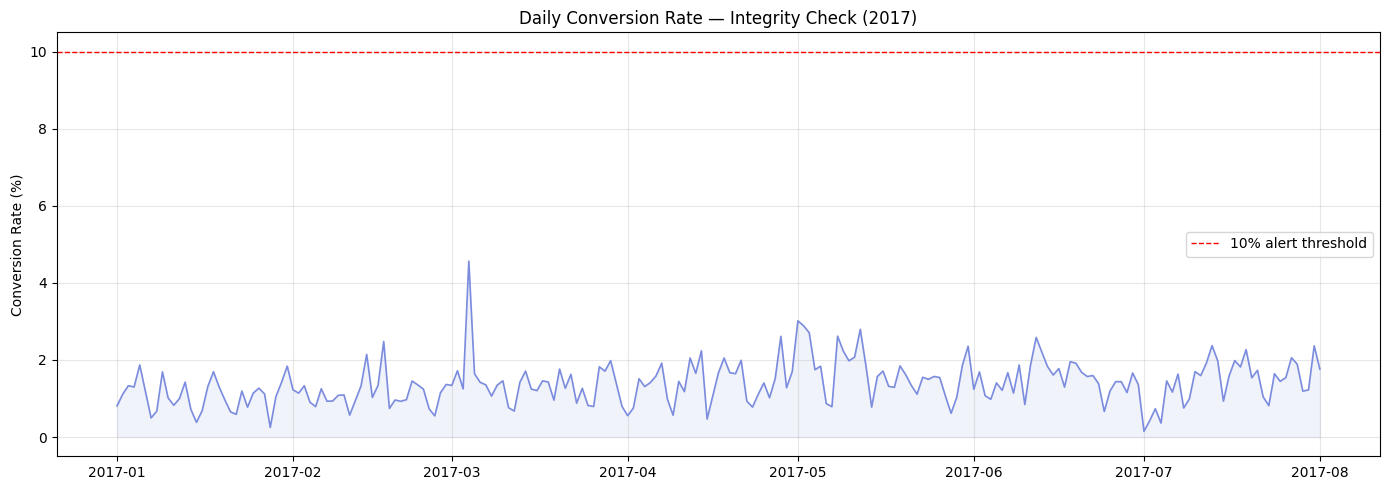

Chart saved.


In [6]:
# Daily conversion rate
df['conversion_rate'] = (df['total_transactions'] / df['total_sessions']) * 100

# Flag suspicious conversion spikes (>10%) or zero conversion days
zero_conversion = df[df['total_transactions'] == 0]
high_conversion = df[df['conversion_rate'] > 10]

print(f"Days with zero transactions: {len(zero_conversion)}")
print(f"Days with conversion rate > 10% (suspicious): {len(high_conversion)}")

# Plot conversion rate
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['conversion_rate'], color='#7B8CDE', linewidth=1.2)
plt.axhline(y=10, color='red', linestyle='--', linewidth=1, label='10% alert threshold')
plt.fill_between(df['date'], df['conversion_rate'], alpha=0.1, color='#7B8CDE')
plt.title('Daily Conversion Rate — Integrity Check (2017)')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/02_conversion_rate_integrity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 7. GTM Tag Audit Summary — Documented Findings

Based on the data integrity checks above, here is the structured audit finding as it would appear in a professional GTM/GA4 tracking review:

### Issue Identified
*Potential misconfiguration:* Revenue spikes on isolated days suggest either promotional event tracking firing duplicate purchase events, or test transactions not filtered from the reporting view.

### Diagnosis Method
- Session vs visit gap analysis to detect duplicate tag fires
- IQR-based outlier detection on daily revenue
- Bounce rate threshold monitoring for tag timing issues
- Conversion rate ceiling checks for suspicious spikes

### Resolution Approach
1. Filter internal IP addresses in GA4 Data Filters to exclude test traffic
2. Audit GTM purchase event trigger — ensure it fires once per transaction confirmation page load only
3. Add deduplication logic using the transaction ID as a unique event parameter
4. Set up GA4 anomaly alerts for daily revenue deviations beyond 2 standard deviations
5. Implement GTM Preview mode testing before every tag deployment

## 8. Save Audit Results

In [7]:
# Save flagged data for reference
df['is_revenue_outlier'] = ((df['total_revenue'] > upper_bound) | 
                             (df['total_revenue'] < lower_bound))
df['is_zero_conversion'] = df['total_transactions'] == 0

df.to_csv('../data/processed/ga_sessions_2017_audited.csv', index=False)

print("=== AUDIT SUMMARY ===")
print(f"Total days analysed:        {len(df)}")
print(f"Revenue outlier days:       {df['is_revenue_outlier'].sum()}")
print(f"Zero conversion days:       {df['is_zero_conversion'].sum()}")
print(f"High bounce days (>80%):    {len(high_bounce)}")
print(f"Low bounce days (<10%):     {len(low_bounce)}")
print(f"\nAudited file saved to data/processed/ga_sessions_2017_audited.csv")

=== AUDIT SUMMARY ===
Total days analysed:        213
Revenue outlier days:       9
Zero conversion days:       0
High bounce days (>80%):    0
Low bounce days (<10%):     0

Audited file saved to data/processed/ga_sessions_2017_audited.csv
